In [28]:
!pip install pandas matplotlib seaborn numpy scikit-learn StandardScaler scikit-learn

Defaulting to user installation because normal site-packages is not writeable
  Using cached standardscaler-0.5-py3-none-any.whl
  Using cached scikit_elm-0.21a0-py3-none-any.whl.metadata (2.8 kB)
  Using cached dask-2025.7.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached cloudpickle-3.1.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached partd-1.4.2-py3-none-any.whl.metadata (4.6 kB)
  Using cached toolz-1.0.0-py3-none-any.whl.metadata (5.1 kB)
  Using cached locket-1.0.0-py2.py3-none-any.whl.metadata (2.8 kB)
Using cached dask-2025.7.0-py3-none-any.whl (1.5 MB)
Using cached scikit_elm-0.21a0-py3-none-any.whl (30 kB)
Using cached cloudpickle-3.1.1-py3-none-any.whl (20 kB)
Using cached partd-1.4.2-py3-none-any.whl (18 kB)
Using cached toolz-1.0.0-py3-none-any.whl (56 kB)
Using cached locket-1.0.0-py2.py3-none-any.whl (4.4 kB)



[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Question 1: Data analysis, EDA, and data visualization
1)Data Loading and Initial Analysis
I begin by loading the dataset directly from Google Drive using its file ID. This approach ensures I'm working with the most current version of the data without manual downloads.This approach ensures I'm working with the most current version of the data without manual downloads.I uploded the dataset folders into a cloud repository (Google Drive). This is  to mirror how production datasets are typically stored in cloud repositories and retrieved through API endpoints in real-world application. 

2)Quick analysis
I immediately examine the first 5 rows to verify proper loading and get a preliminary understanding of the dataset's structure. This helps me identify obvious issues like misaligned column or irregular characters.By calling df.info(), I check for the column count and names relevance to our analysis. I also do a Non-null counts for initial missing value check. I create a dedicated missing value report showing both absolute counts and percentages. This prioritizes columns needing attention. The percentage view is important because a column with 100 missing entries might not be much in a 100,000 row dataset however it is critical in a 10000 row dataset.

3)Date preprocessing and Cleaning
I explicitly create a copy of the original DataFrame df_clean = df.copy() as a way to keep the raw data untouched. Cleaning and transformations are done on a copy, so if I make an error, I can restart from the original without reloading. I then execute these cleaning steps:
(i)Duplicate Removal: I first identify and remove exact duplicate rows because they artificially inflate record counts and distort statistics. By printing counts before/after removal, I demonstrate the process transparency.
(ii)String Standardisation: I remove leading/trailing whitespace that causes false distinction. I also convert any small letter case to title case for consistency.Finally I replace placeholder strings like 'Nan' with actual NaN values to prevent misleading category.
(iii)Numeric Column Validation: For numerical fields like 'Engine HP' and 'city mpg' as an example, I force conversion to numeric types using pd.to_numeric(). The errors='coerce' parameter converts unparsable values like "N/A" or "—" to NaN. This is to ensure that type error failure dont occure

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1.1 Load from Google Drive  
def load_drive_csv():
    file_id = '17PzQ6-Ww_8RIapJ8_jeQ7L-LWEIVaQ2M'
    url = f'https://drive.google.com/uc?export=download&id={file_id}'
    df = pd.read_csv(url)
    print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
    return df

# Show first few rows
print("\n" + "First Few Rows")
print("="*50)

def quick_analysis(df):
    print("First Few Rows:")
    print(df.head())
    print("="*50)
    
    print("Dataset Info:")
    print(df.info())
    print("="*50)
    
    print("Basic Stats:")
    print(df.describe())
    print("="*50)

    print("Missing Values:")
    missing_counts = df.isnull().sum()
    missing_percent = (missing_counts / len(df)) * 100
    missing_df = pd.DataFrame({
        'Missing Count': missing_counts,
        'Missing Percentage': missing_percent.round(2)
    })
    print(missing_df[missing_df['Missing Count'] > 0])
    print("="*50)

df = load_drive_csv()
quick_analysis(df)

# 1.1 Data preprocessing and cleaning
def preprocess_data(df):
    """
    Clean and preprocess the dataset
    """
    print("\n" + "="*50)
    print("Data Preprocessing and Cleaning")
    print("="*50)
    
    # Create a copy  
    df_clean = df.copy()
    
    # Checking for duplicate
    print(f"\nDuplicate rows: {df_clean.duplicated().sum()}")
    df_clean = df_clean.drop_duplicates()
    print(f"After removing duplicates: {df_clean.shape}")
    
    # String cleaning for columns
    string_columns = ['Make', 'Model', 'Engine Fuel Type', 'Transmission Type','Driven_Wheels', 'Market Category', 'Vehicle Size', 'Vehicle Style']
    print("\nCleaning string columns:")
    for col in string_columns:
        if col in df_clean.columns:
            # Strip whitespace and convert to title case
            df_clean[col] = df_clean[col].astype(str).str.strip().str.title()
            # Replace 'Nan' string with actual NaN
            df_clean[col] = df_clean[col].replace('Nan', np.nan)
    
    # Clean numeric columns
    numeric_columns = ['Year', 'Engine HP', 'Engine Cylinders', 'Number of Doors','highway MPG', 'city mpg', 'Popularity', 'MSRP']
    for col in numeric_columns:
        if col in df_clean.columns:
            # Ensure numeric values are formatted
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    
    print("String cleaning is completed")
    return df_clean
df_clean= preprocess_data(df)



First Few Rows
Loaded: 11914 rows, 16 columns
First Few Rows:
  Make       Model  Year             Engine Fuel Type  Engine HP  \
0  BMW  1 Series M  2011  premium unleaded (required)      335.0   
1  BMW    1 Series  2011  premium unleaded (required)      300.0   
2  BMW    1 Series  2011  premium unleaded (required)      300.0   
3  BMW    1 Series  2011  premium unleaded (required)      230.0   
4  BMW    1 Series  2011  premium unleaded (required)      230.0   

   Engine Cylinders Transmission Type     Driven_Wheels  Number of Doors  \
0               6.0            MANUAL  rear wheel drive              2.0   
1               6.0            MANUAL  rear wheel drive              2.0   
2               6.0            MANUAL  rear wheel drive              2.0   
3               6.0            MANUAL  rear wheel drive              2.0   
4               6.0            MANUAL  rear wheel drive              2.0   

                         Market Category Vehicle Size Vehicle Style  \


<b>Question 1.2 </b>
Below is how I handle missing values. First I try to determine whether the column contains continuous numerical values such as in Engine HP or discrete values as seen in Engine Cylinders, Number of Doors, Engine Fuel Type. Based on the type of data, I would assign appropriate imputation method that is appropriate with its context taken into account for as well.For Engine HP column,I replace the missing values with median values. Since the data is continous values,median is choosen as it is less affected by outliers and provide better central tendency for skewed data compared to the mean.

For discrete numerical or categorical columns like Engine Cylinders, Number of Doors, and Engine Fuel Type, I replace missing values with the mode (most frequent value) .This is done to ensure the most common category in the dataset is represented and remained. Furthermore, values such as Number of Doors and Engine Cylinders must be a whole number since it represent a count,therefore applying mean will result in those column having decimals which doesnt make sense for the column context.

For the Market Category column, many entries are not specified and is marked with 'N/A'.Hence I fill missing values with "Not Specified" to indicate the absence of a category rather than incorrectly imputing a value.This approach ensures that I dont introduce any bias to the data with that placeholder category. 


In [31]:
def handle_missing_values(df):
    print("\n" + "="*50)
    print("MISSING VALUES HANDLING")
    print("="*50)
    
    df_imputed = df.copy()
    # Using median imputation for numerical columns that are continues values
    num_col_missing = ['Engine HP']
    for col in num_col_missing:
        if col in df_imputed.columns and df_imputed[col].isnull().sum() > 0:
            missing_count = df_imputed[col].isnull().sum()
            median_val = df_imputed[col].median()
            
            # Filling in the missing values
            df_imputed[col] = df_imputed[col].fillna(median_val)
            
            print(f"✓ {col}:")
            print(f"  - Missing values: {missing_count}")
            print(f"  - Filled with median: {median_val}")
    # Using mode imputation for numerical columns that are discrete
    discrete_columns = ['Engine Cylinders', 'Number of Doors','Engine Fuel Type']
    for col in discrete_columns:
        if col in df_imputed.columns and df_imputed[col].isnull().sum() > 0:
            missing_count = df_imputed[col].isnull().sum()
            mode_val = df_imputed[col].mode().iloc[0]
            
            # Filling in the missing values
            df_imputed[col]=df_imputed[col].fillna(mode_val)
            print(f"✓ {col}:")
            print(f"    - Missing values: {missing_count}")
            print(f"    - Filled with mode: {mode_val}")
    #Filling in Market Category columns with special string
    if 'Market Category' in df_imputed.columns and df_imputed['Market Category'].isnull().sum() > 0:
        missing_count = df_imputed['Market Category'].isnull().sum()
        missing_percent_market = (missing_count / len(df_imputed)) * 100
        
        # Fill with 'Not Specified' since many cars don't fall into specific market categories
        df_imputed['Market Category']=df_imputed['Market Category'].fillna('Not Specified')
        
        print(f"✓ Market Category:")
        print(f"    - Missing values: {missing_count} ({missing_percent_market:.1f}%)")
    
    return df_imputed

df_final = handle_missing_values(df_clean)
#Verify is missing value is handled correctly
print(f"Final shape: {df_final.shape}")
print(f"Total missing values: {df_final.isnull().sum().sum()}")


MISSING VALUES HANDLING
✓ Engine HP:
  - Missing values: 69
  - Filled with median: 239.0
✓ Engine Cylinders:
    - Missing values: 30
    - Filled with mode: 4.0
✓ Number of Doors:
    - Missing values: 6
    - Filled with mode: 4.0
✓ Engine Fuel Type:
    - Missing values: 3
    - Filled with mode: Regular Unleaded
✓ Market Category:
    - Missing values: 3376 (30.1%)
Final shape: (11199, 16)
Total missing values: 0


<b>Question 1.3 </b>
1.3 a)To explore the relationship between Engine Horsepower and City MPG, I first created a scatter plot with a regression line overlay. This allows for both a visual and statistical assessment of the relationship.
From the scatter plot, it is clear that as Engine Horsepower increases, City MPG tends to decrease. The points are more concentrated at lower horsepower values, but the downward trend remains consistent. The inference that can be drawn from this chart are the vehicles with more powerful engines tend to have lower fuel efficiency in city driving.
The Pearson correlation coefficient is -0.355, indicating a weak to moderate inverse relationship between the two variables.In summary, the evidence show that higher engine horsepower is associated with less efficiency in city fuel usage.

1.3 Highlight and summarize, statistically and visually,
3a) Engine Horsepower and City MPG


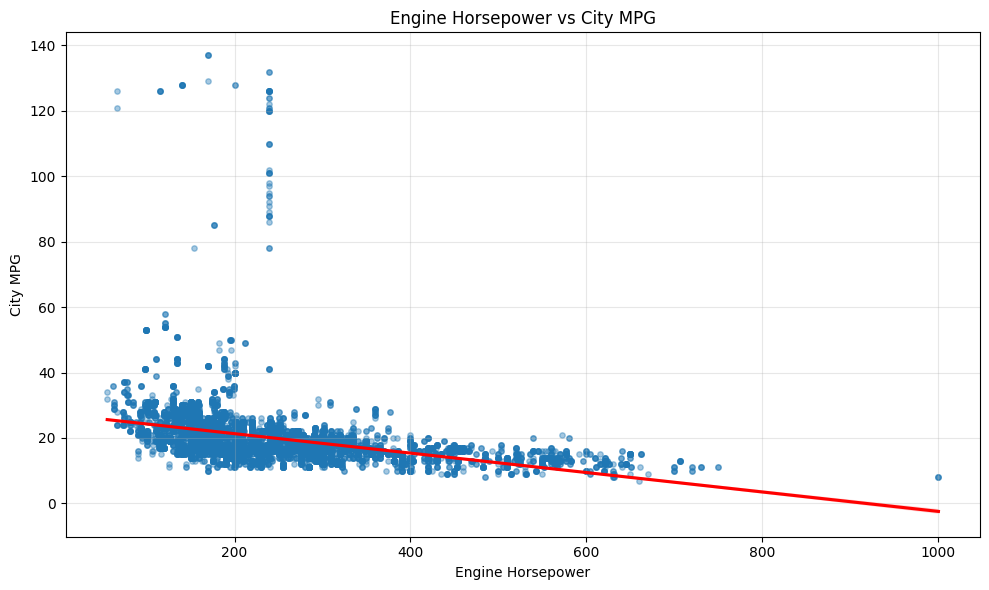

Correlation (Horsepower vs City MPG): -0.355


In [32]:
# SECTION 3: STATISTICAL AND VISUAL ANALYSIS
print("1.3 Highlight and summarize, statistically and visually,")
print("="*50)

# 3a) Horsepower vs City Mileage
print("3a) Engine Horsepower and City MPG")
print("="*50)
plt.figure(figsize=(10, 6))
sns.regplot(x='Engine HP', y='city mpg', data=df_final, 
            scatter_kws={'alpha':0.4, 's':15}, 
            line_kws={'color':'red'})
plt.title('Engine Horsepower vs City MPG')
plt.xlabel('Engine Horsepower')
plt.ylabel('City MPG')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('hp_vs_citympg.png', dpi=300)
plt.show()

# Calculate correlation
corr_hp_mpg = df_final['Engine HP'].corr(df_final['city mpg'])
print(f"Correlation (Horsepower vs City MPG): {corr_hp_mpg:.3f}")


1.3 b) For variables of Transmission Type and Vehicle Style, I created a heatmap showing the percentage distribution of each transmission type across different vehicle styles.Certain vehicle styles are strongly associated with specific transmission types. Here is what is derived based on the observations made on he heatmap.

-Direct Drive is overwhelmingly dominant in 4Dr Hatchbacks (54.4%).
-Automated Manual is most common in Sedans (32.2%) and Convertibles(22.4%).
-Manual transmissions are frequently found in Coupes (21.1%) and Sedans (19.1%).
-Automatic transmissions dominate in 4Dr SUVs (29.2%) and Sedans (27.0%)
The statistical summary confirms the above observations, listing the top three vehicle styles for each transmission type.
A heatmap was chosen for this analysis because it effectively represents percentage distributions in a matrix format which allow quick recognition on pattern formation.It is also suitable when both variables are categorical columns.





3b) Transmission Type and Vehicle Style


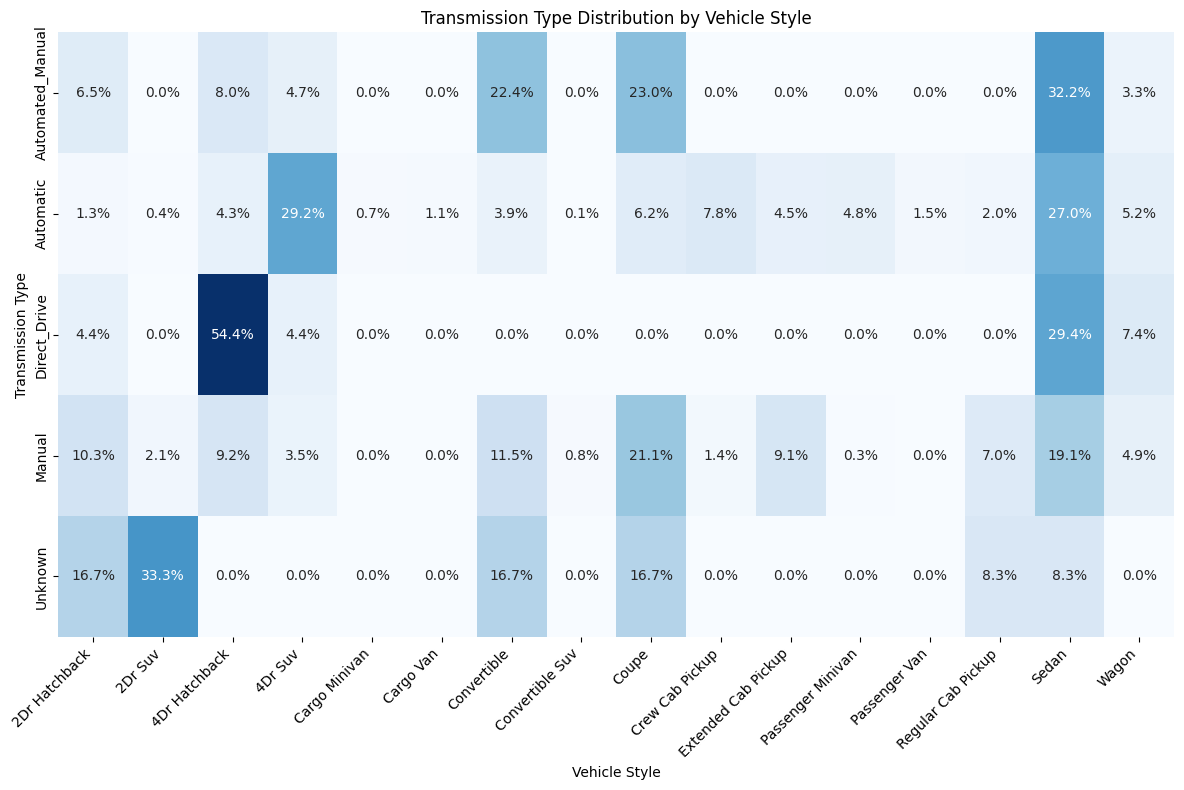


Top 3 Vehicle Styles per Transmission Type:

Manual:
  - Coupe: 555 vehicles (21.1%)
  - Sedan: 503 vehicles (19.1%)
  - Convertible: 302 vehicles (11.5%)

Automatic:
  - 4Dr Suv: 2314 vehicles (29.2%)
  - Sedan: 2141 vehicles (27.0%)
  - Crew Cab Pickup: 618 vehicles (7.8%)

Automated_Manual:
  - Sedan: 178 vehicles (32.2%)
  - Coupe: 127 vehicles (23.0%)
  - Convertible: 124 vehicles (22.4%)

Direct_Drive:
  - 4Dr Hatchback: 37 vehicles (54.4%)
  - Sedan: 20 vehicles (29.4%)
  - Wagon: 5 vehicles (7.4%)

Unknown:
  - 2Dr Suv: 4 vehicles (33.3%)
  - Coupe: 2 vehicles (16.7%)
  - Convertible: 2 vehicles (16.7%)


In [33]:
# 3b) Transmission Type vs Vehicle Style
print("\n3b) Transmission Type and Vehicle Style")
print("="*50)

# Prepare data
cross_tab = pd.crosstab(df_final['Transmission Type'], 
                        df_final['Vehicle Style'],
                        normalize='index')

plt.figure(figsize=(12, 8))
sns.heatmap(cross_tab, annot=True, fmt='.1%', cmap='Blues', cbar=False)
plt.title('Transmission Type Distribution by Vehicle Style')
plt.xlabel('Vehicle Style')
plt.ylabel('Transmission Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('transmission_vs_style.png', dpi=300)
plt.show()

# Statistical summary
print("\nTop 3 Vehicle Styles per Transmission Type:")
for transmission in df_final['Transmission Type'].unique():
    subset = df_final[df_final['Transmission Type'] == transmission]
    top_styles = subset['Vehicle Style'].value_counts().nlargest(3)
    print(f"\n{transmission}:")
    for style, count in top_styles.items():
        print(f"  - {style}: {count} vehicles ({count/len(subset):.1%})")

1.3 c)For Engine Horsepower across different Transmission Types, I used a box plot. The usage behind box plot is useful because it shows the median, overall spread, and any outliers in the data, making it easier to see how horsepower varies between transmission types.The horsepower statistics show that Automatic transmissions have the highest median horsepower(260 HP),indicating a consistent performance range.Automated Manual transmissions, despite having a slightly lower median (252 HP), have the highest mean (336.8 HP) and largest standard deviation (175.9).An inference can be made from automated manual transmission which sugegst there is a wide range of vehicles that include extreme high performance vehicles that skew the mean towards higher.Direct Drive transmissions have a lower median (239 Hp) and a small spread (std 48.6).In summary,Overall, the Automatic transmissions dominate in raw horsepower however Automated Manuals have a more broader range of performance.


3c) Transmission Type and Engine Horsepower
--------------------------------------------------


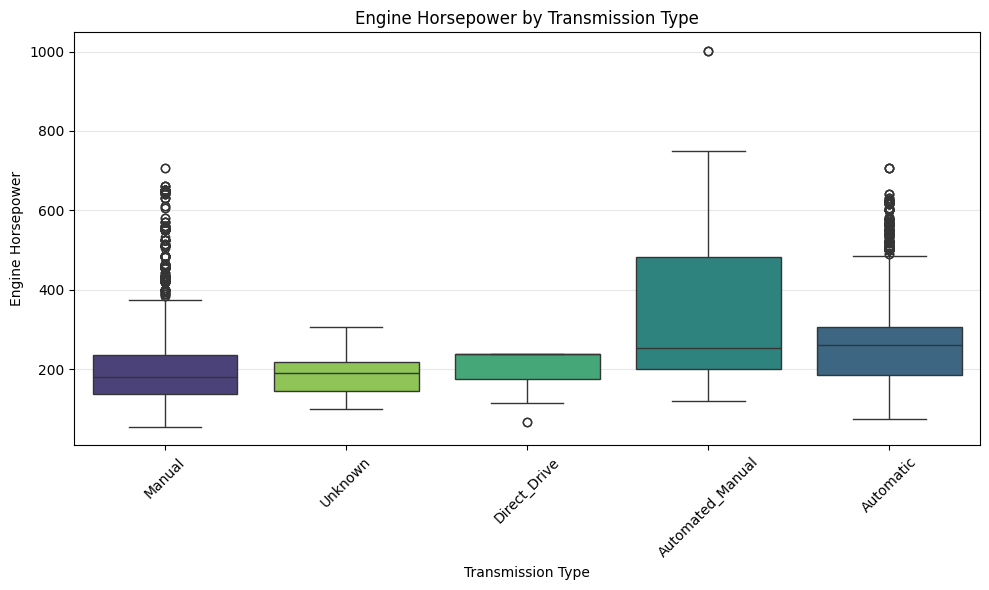


Horsepower Statistics by Transmission Type:
                   median        mean         std
Transmission Type                                
Automatic           260.0  260.880862   95.526278
Automated_Manual    252.0  336.797468  175.890989
Direct_Drive        239.0  207.014706   48.552324
Unknown             190.0  191.666667   75.838744
Manual              179.0  214.417616  118.364742


In [34]:
# 3c) Transmission Type vs Engine Horsepower
print("\n3c) Transmission Type and Engine Horsepower")
print("-"*50)

plt.figure(figsize=(10, 6))
order = df_final.groupby('Transmission Type')['Engine HP'].median().sort_values().index
sns.boxplot(x='Transmission Type',hue='Transmission Type', y='Engine HP', data=df_final, 
            order=order, palette='viridis',legend=False)
plt.title('Engine Horsepower by Transmission Type')
plt.xlabel('Transmission Type')
plt.ylabel('Engine Horsepower')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('transmission_vs_hp.png', dpi=300)
plt.show()

# Statistical summary
hp_stats = df_final.groupby('Transmission Type')['Engine HP'].agg(['median', 'mean', 'std'])
print("\nHorsepower Statistics by Transmission Type:")
print(hp_stats.sort_values('median', ascending=False))

1.3 d)
I used a heatmap to display the correlation matrix of all numerical columns. This visualization is ideal for showing relationships between multiple variables. The heatmap's color gradient from blue(strong negative correlation) to red(strong positive correlation) simplify myself to identify strong relationships without needing to read every number.
The most notable correlation is between Highway MPG and City MPG (r=0.89). This indicates as the number of highway miles per gallon increases, the city miles per gallon also tends to increase significantly.Other  notable correlation is between Engine Horsepower and Engine Cylinders(r=0.77). This indicates a very strong correlation relationship, meaning as the number of cylinders increases, the horsepower of the engine also tends to increase as well. This is quite logical finding, as more cylinders generally equate to a more powerful engine.

The threshold of ∣r∣>0.7 is a commonly used rule of thumb to define a strong correlation in statistical analysis.The code also detected other instances of this same relationship,confirming the correlation between for example highway MPG and city mpg is the same as between city mpg and highway MPG.


3d)Correlation Matrix for Numerical Columns


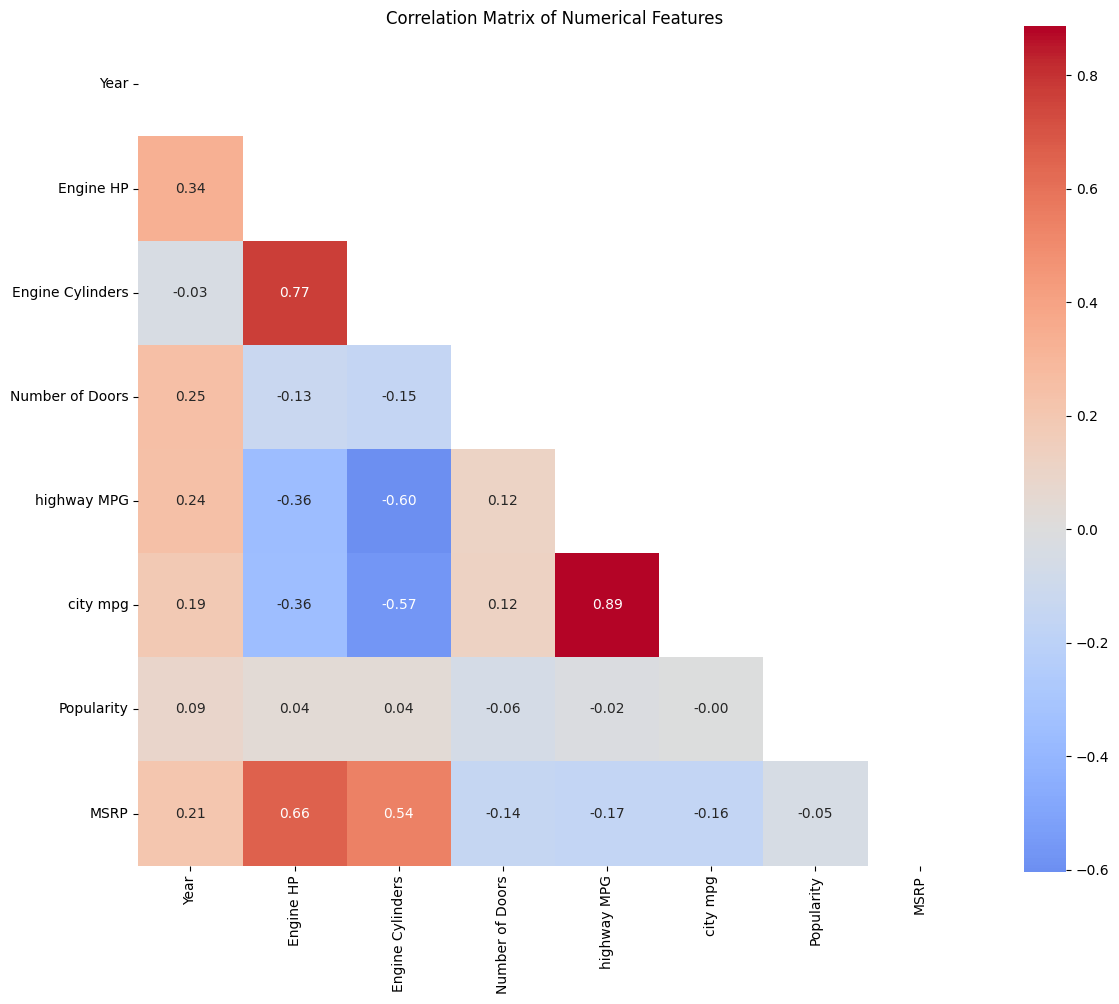


Strongest Correlations (|r| > 0.7):
highway MPG       city mpg            0.886299
city mpg          highway MPG         0.886299
Engine HP         Engine Cylinders    0.774299
Engine Cylinders  Engine HP           0.774299
dtype: float64


In [35]:
#3d) Correlation between all numerical column
print("\n3d)Correlation Matrix for Numerical Columns")
print("="*50)

# Select numerical columns
numeric_columns = df_final.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(12, 10))
correlation_matrix = df_final[numeric_columns].corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300)
plt.show()

# Highlight strong correlations
print("\nStrongest Correlations (|r| > 0.7):")
strong_corr = correlation_matrix.unstack().sort_values(ascending=False)
strong_corr = strong_corr[(strong_corr > 0.7) & (strong_corr < 1)]
print(strong_corr)

SECTION 1.4 

Below is the overview of the clustring process:
 1)Feature Selection
 I look at the dataset and see which numerical features would be meaningful for clustering cars.Features like 'Engine HP','city mpg', 'highway MPG' , 
'MSRP', and 'Engine Cylinders'are chosen  due to them being characteristics that define a car's performance and category.An example if a low Engine HP and High City MP might indicate the car is an economy car with low horsepower and high fuel efficiency.

2)Standardisation of features
 I notice that the features are on different scale of measurements. For example, 'MSRP' are in the tens of thousands while 'Engine Cylinders' is usually between 1-10.Since K-Mean uses Euclidean distance, features with larger scales would skew the cluster with biasness.Therefore, I standardize the features by using scale method to minimise difference in mean and variance.
 
3)Determine the optimal K value
To decide how many clusters K to use, I choose the Elbow method because it is easy to interpret from a visual standpoint.I run K-Mean for a range of k values which is 1 to 10 and compute the within cluster sum of squares (WCSS) for each k.I watch for the K point where adding more clusters yields diminishing returns. The chart suggests k=4 is most meaningful segmentation without overcomplicating the model





In [37]:
import matplotlib.pyplot as plt

# 1. Numerical featurez for clustering
cluster_features = [
    'Engine HP', 
    'city mpg', 
    'highway MPG', 
    'MSRP', 
    'Engine Cylinders'
]
X = df_final[cluster_features]

# 2. Standardise features (crucial for distance-based algorithms)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Find optimal clusters with the Elbow Method
wcss = []  # Within-Cluster-Sum-of-Squares
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

#Elbow curve plot
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal Cluster Number')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

NameError: name 'StandardScaler' is not defined


4) Applying the K mean clustering
With k=4, I run the K-Means algorithm on the scaled data. I assign the cluster labels to the dataframe for further analysis.
    
5) Plotting the cluster using scatter plot
I visualize the clusters using a scatter plot of two key features:'Engine Hp' and 'city mpg' . This helps in seeing the clusters in two dimensions. The reason why I choose these two features is because the car horsepower and its fuel efficiency are factors that influence the purchasing of a car this is proved useful for consumers.Adding transparency (alpha=0.8) helps mitigate overplotting issues for visual experience


6)Analysis of the results
When analyzing the cluster summary statistics,I can derive several inference on which consumer target can be made for the market based on the observation of the scatter plot positions.Cluster 0 has Moderate HP, Low MPG. This most likely represent a m
Cluster 1 has Low HP, High MPG which means Cluster 1 represents economy car. Cluster 2 represent Moderate HP, Extremely High MPG.Cluster 3 represents  Very High HP, Very Low MPG which translates to supercar such as sport cars.
                                                                                                       




In [38]:
# In applying the k mean clusters,I decide to choose k=4 based on the elbow plot 
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to the dataframe
df_final['Cluster'] = clusters

# Plot Engine HP vs. City MPG colored by cluster
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_final, 
    x='Engine HP', 
    y='city mpg', 
    hue='Cluster', 
    palette='viridis',
    alpha=0.8
)
plt.title('Car Clusters: Horsepower vs. City Fuel Efficiency')
plt.xlabel('Engine Horsepower')
plt.ylabel('City MPG')
plt.show()

# Cluster summary
cluster_summary = df_final.groupby('Cluster')[cluster_features].mean()
print(cluster_summary)

NameError: name 'KMeans' is not defined